In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io
import matplotlib.dates as mdates
import datetime

DATOS VALLADOLID

In [2]:
df = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\evolucion_predicciones\semana_valladolid\resultados_231757\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

# real = df['Real (m)']
# predicho = df['Predicho (m)']
# error = df['Error (m)']
nombre=df['Nombre de Imagen']

#Separo la información del nombre de la imagen en días y horas
partes_nombre = nombre.str.split('_', expand=True)

fecha = partes_nombre[1]        # '20240224'
tiempo_ext = partes_nombre[2]   # '2034.jpg'

# Quitamos el .jpg
tiempo = tiempo_ext.str.replace('.jpg', '', regex=False) # Divide según el punto y el .jpg lo sustituye por texto en blanco

df['Fecha_Completa'] = pd.to_datetime(fecha + tiempo, format='%Y%m%d%H%M')
df = df.sort_values(by='Fecha_Completa')

print(df)

           Nombre de Imagen  Real (m)  Predicho (m)  Error (m)  \
212  C013_20230812_0000.jpg    8260.0       4625.21   -3634.79   
67   C013_20230812_0002.jpg    8249.0       6681.77   -1567.23   
69   C013_20230812_0004.jpg    8248.0       7182.00   -1066.00   
224  C013_20230812_0006.jpg    8258.0       5947.63   -2310.37   
264  C013_20230812_0008.jpg    8265.0       5717.31   -2547.69   
..                      ...       ...           ...        ...   
58   C013_20230818_1045.jpg    6189.0       7283.34    1094.34   
265  C013_20230818_1210.jpg    5170.0       7297.90    2127.90   
174  C013_20230818_1215.jpg    5136.0       8537.64    3401.64   
26   C013_20230818_1220.jpg   10430.0       8532.87   -1897.13   
189  C013_20230818_1230.jpg    5845.0       9129.01    3284.01   

         Fecha_Completa  
212 2023-08-12 00:00:00  
67  2023-08-12 00:02:00  
69  2023-08-12 00:04:00  
224 2023-08-12 00:06:00  
264 2023-08-12 00:08:00  
..                  ...  
58  2023-08-18 10:45:00  

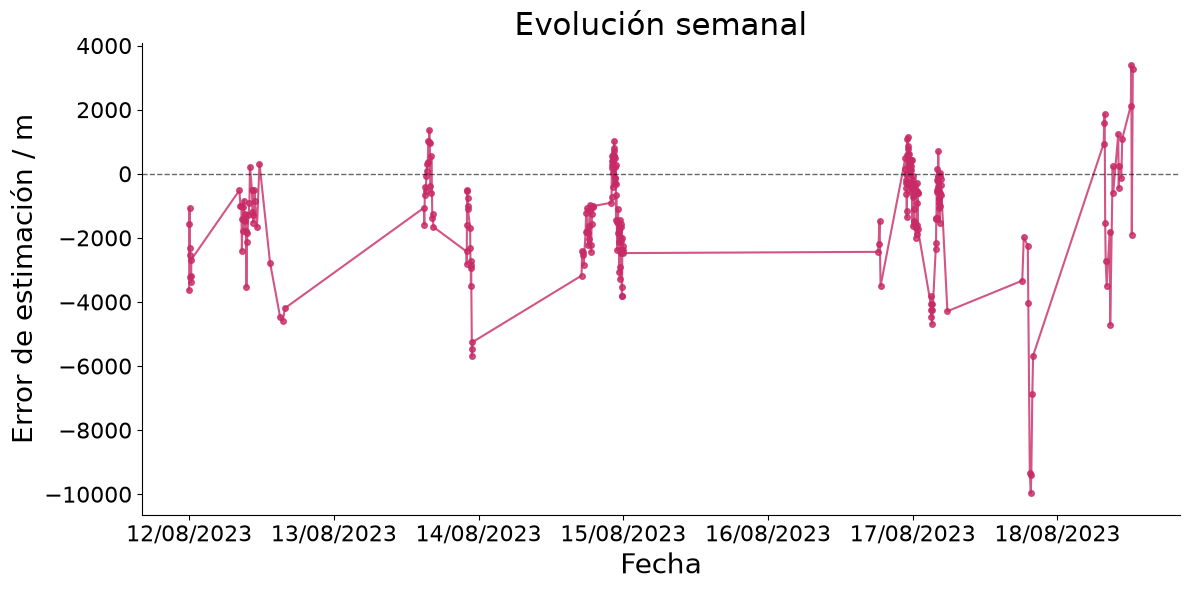

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df['Fecha_Completa'], df['Error (m)'], color='#C72A66', marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8)
# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

#formato_fecha = mdates.DateFormatter('%d/%m/%Y %H:%M')
formato_fecha = mdates.DateFormatter('%d/%m/%Y')
ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución semanal', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [4]:
datos_por_dia = df['Fecha_Completa'].dt.date.value_counts().sort_index()

print("Número de datos por día:")
print(datos_por_dia)

Número de datos por día:
Fecha_Completa
2023-08-12    39
2023-08-13    36
2023-08-14    73
2023-08-16    39
2023-08-17    64
2023-08-18    19
Name: count, dtype: int64


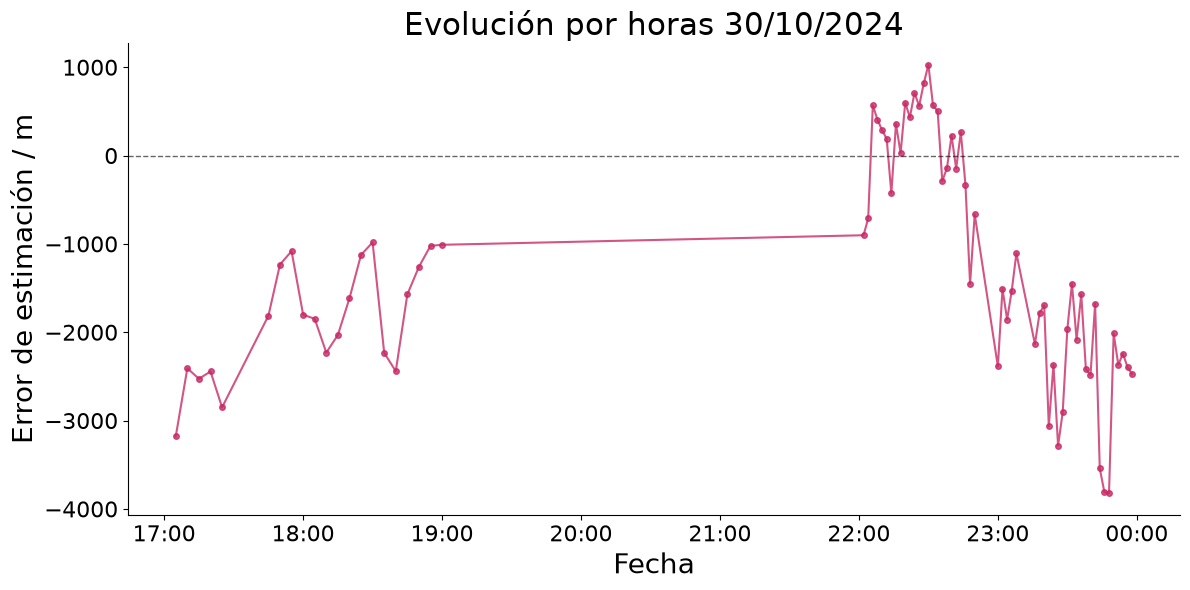

In [7]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dia = datetime.date(2023,8,14)

# Nuevo data frame
df_dia = df[df['Fecha_Completa'].dt.date == dia]


fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df_dia['Fecha_Completa'], df_dia['Error (m)'], color='#C72A66', marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8)
# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución por horas 30/10/2024', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

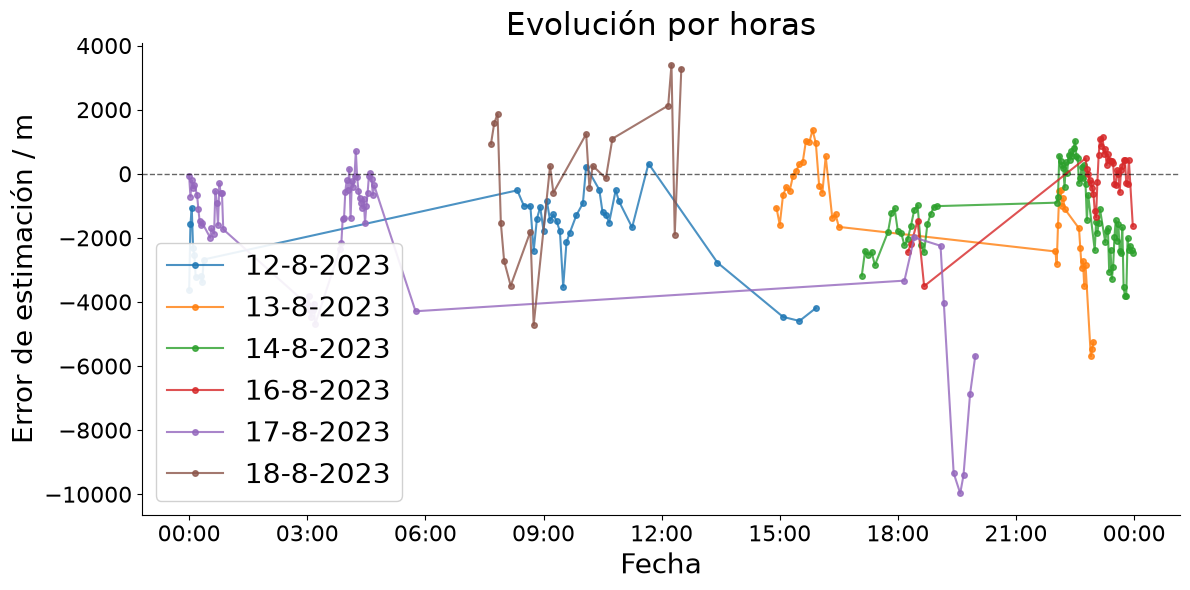

In [6]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dias = df['Fecha_Completa'].dt.date.sort_index()
lista_dias = sorted(list(set(dias)))

fig, ax = plt.subplots(figsize=(12, 6))

for dia in lista_dias:
    # if dia == datetime.date(2024,10,26):
    #     continue
    # Nuevo data frame
    df_dia = df[df['Fecha_Completa'].dt.date == dia]
    fecha_auxiliar = pd.to_datetime(df_dia['Fecha_Completa'].dt.strftime('2000-01-01 %H:%M:%S')) #ponemos a todos los días la misma fecha para que colapsen en el plot
    ax.plot(fecha_auxiliar, df_dia['Error (m)'], marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8, label=f'{dia.day}-{dia.month}-{dia.year}')



# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución por horas', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(loc='lower left', framealpha=0.9, facecolor='white', fontsize=20)

plt.tight_layout()
plt.show()